**Chương 9 – Học không giám sát**

_Cuốn sổ tay này chứa tất cả mã mẫu và giải pháp cho các bài tập trong chương 9._

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/09_unsupervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/09_unsupervised_learning.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Thiết lập

Dự án này yêu cầu Python 3.7 trở lên.

In [ ]:
import sys

assert sys.version_info >= (3, 7)

Nó cũng yêu cầu Scikit-Learn ≥ 1.0.1.

In [ ]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

Như chúng ta đã làm ở các chương trước, hãy định nghĩa kích thước phông chữ mặc định để làm cho các hình ảnh đẹp hơn:

In [ ]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

Và hãy tạo thư mục images/unsupervised_learning (nếu nó chưa tồn tại), và định nghĩa hàm save_fig() mà sẽ được sử dụng trong toàn bộ cuốn sổ này để lưu các hình ảnh với độ phân giải cao cho cuốn sách:

In [ ]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "unsupervised_learning"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

Đầu tiên, hãy nhập một vài mô-đun phổ biến, đảm bảo rằng Matplotlib vẽ hình ảnh ngay trong dòng và chuẩn bị một hàm để lưu các hình ảnh.

# Phân nhóm

**Giới thiệu – Phân loại so với Nhóm**

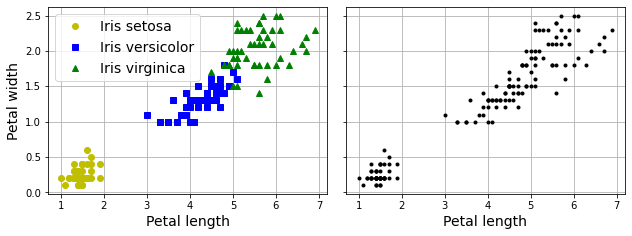

In [ ]:
# extra code – this cell generates and saves Figure 9–1

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

data = load_iris()
X = data.data
y = data.target
data.target_names

plt.figure(figsize=(9, 3.5))

plt.subplot(121)
plt.plot(X[y==0, 2], X[y==0, 3], "yo", label="Iris setosa")
plt.plot(X[y==1, 2], X[y==1, 3], "bs", label="Iris versicolor")
plt.plot(X[y==2, 2], X[y==2, 3], "g^", label="Iris virginica")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.grid()
plt.legend()

plt.subplot(122)
plt.scatter(X[:, 2], X[:, 3], c="k", marker=".")
plt.xlabel("Petal length")
plt.tick_params(labelleft=False)
plt.gca().set_axisbelow(True)
plt.grid()

save_fig("classification_vs_clustering_plot")
plt.show()

**Lưu ý**: ô tiếp theo cho thấy cách **mô hình hỗn hợp Gaussian** (được giải thích sau trong chương này) thực sự có thể phân tách các cụm này khá tốt bằng cách sử dụng cả 4 đặc trưng: chiều dài & chiều rộng cánh hoa, và chiều dài & chiều rộng đài hoa. Mã này ánh xạ mỗi cụm thành một lớp. Thay vì mã hóa cứng ánh xạ, mã chọn lớp phổ biến nhất cho mỗi cụm bằng cách sử dụng hàm `scipy.stats.mode()`:

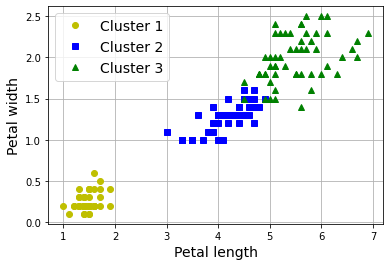

In [ ]:
# extra code

import numpy as np
from scipy import stats
from sklearn.mixture import GaussianMixture

y_pred = GaussianMixture(n_components=3, random_state=42).fit(X).predict(X)

mapping = {}
for class_id in np.unique(y):
    mode, _ = stats.mode(y_pred[y==class_id])
    mapping[mode] = class_id

y_pred = np.array([mapping[cluster_id] for cluster_id in y_pred])

plt.plot(X[y_pred==0, 2], X[y_pred==0, 3], "yo", label="Cluster 1")
plt.plot(X[y_pred==1, 2], X[y_pred==1, 3], "bs", label="Cluster 2")
plt.plot(X[y_pred==2, 2], X[y_pred==2, 3], "g^", label="Cluster 3")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="upper left")
plt.grid()
plt.show()

Tỷ lệ số cây iris mà chúng ta đã gán vào cụm đúng là bao nhiêu?

In [ ]:
(y_pred==y).sum() / len(y_pred)

0.9666666666666667

## K-Means

**Huấn luyện và dự đoán**

Hãy huấn luyện một **bộ phân cụm K-Trung bình** (K-Means clusterer) trên một tập dữ liệu gồm các **khối** (blobs). Nó sẽ cố gắng tìm ra **tâm** của mỗi khối và gán mỗi **thể hiện** (instance) vào khối gần nhất:

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# extra code – the exact arguments of make_blobs() are not important
blob_centers = np.array([[ 0.2,  2.3], [-1.5 ,  2.3], [-2.8,  1.8],
                         [-2.8,  2.8], [-2.8,  1.3]])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])
X, y = make_blobs(n_samples=2000, centers=blob_centers, cluster_std=blob_std,
                  random_state=7)

k = 5
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
y_pred = kmeans.fit_predict(X)

**Lưu ý**: Xuyên suốt notebook này, khi tham số `n_init` không được đặt khi tạo một bộ ước lượng `KMeans`, tôi đã **tường minh** (explicitly) đặt nó thành `n_init=10` để tránh một cảnh báo về việc giá trị mặc định cho siêu tham số này sẽ thay đổi từ 10 thành `"auto"` trong Scikit-Learn phiên bản 1.4.

Bây giờ chúng ta hãy vẽ chúng:

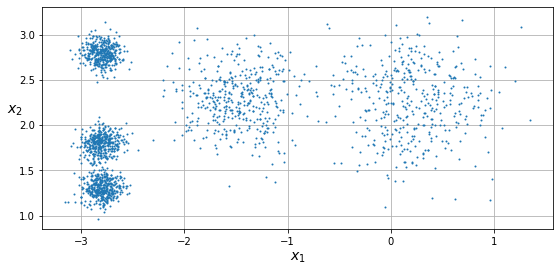

In [ ]:
# extra code – this cell generates and saves Figure 9–2

def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$", rotation=0)

plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.gca().set_axisbelow(True)
plt.grid()
save_fig("blobs_plot")
plt.show()

Mỗi thể hiện (instance) được gán vào một trong 5 cụm:

In [ ]:
y_pred

array([4, 0, 1, ..., 2, 1, 0], dtype=int32)

In [ ]:
y_pred is kmeans.labels_

True

Và 5 tâm cụm (centroid) (tức là trung tâm cụm) sau đây đã được ước tính:

In [ ]:
kmeans.cluster_centers_

array([[-2.80389616,  1.80117999],
       [ 0.20876306,  2.25551336],
       [-2.79290307,  2.79641063],
       [-1.46679593,  2.28585348],
       [-2.80037642,  1.30082566]])

**Lưu ý** rằng thể hiện (`KMeans` instance) **bảo toàn nhãn** (labels) của các thể hiện mà nó được huấn luyện. Hơi khó hiểu, nhưng trong ngữ cảnh này, **nhãn** (label) của một thể hiện là **chỉ số** của cụm mà thể hiện đó được gán vào (chúng không phải là mục tiêu *targets*, mà là các dự đoán *predictions*):

In [ ]:
kmeans.labels_

array([4, 0, 1, ..., 2, 1, 0], dtype=int32)

Tất nhiên, chúng ta có thể dự đoán các nhãn của các thể hiện mới:

In [ ]:
import numpy as np

X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([1, 1, 2, 2], dtype=int32)

**Ranh giới Quyết định**

Hãy vẽ các **ranh giới quyết định** của mô hình. Điều này cho chúng ta một **sơ đồ Voronoi** (Voronoi diagram):

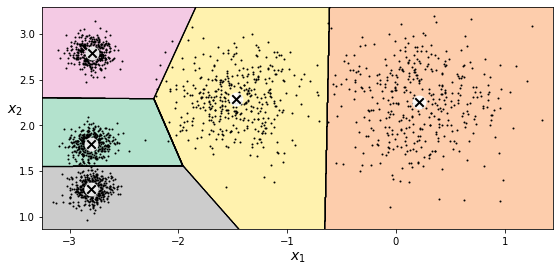

In [ ]:
# extra code – this cell generates and saves Figure 9–3

def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=35, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=12,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)

plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
save_fig("voronoi_plot")
plt.show()

Không tồi! Một số thể hiện gần các cạnh có lẽ đã bị gán nhầm cụm, nhưng nhìn chung thì nó khá tốt.

**Phân cụm Cứng (Hard Clustering) so với Phân cụm Mềm (Soft Clustering)**

Thay vì chọn một cách tùy tiện cụm gần nhất cho mỗi thể hiện—điều được gọi là **phân cụm cứng** (*hard clustering*)—sẽ tốt hơn nếu đo khoảng cách của mỗi thể hiện đến tất cả 5 **tâm cụm** (centroids). Đây là điều mà phương thức `transform()` thực hiện:

In [ ]:
kmeans.transform(X_new).round(2)

array([[2.81, 0.33, 2.9 , 1.49, 2.89],
       [5.81, 2.8 , 5.85, 4.48, 5.84],
       [1.21, 3.29, 0.29, 1.69, 1.71],
       [0.73, 3.22, 0.36, 1.55, 1.22]])

Bạn có thể xác minh rằng đây thực sự là khoảng cách Euclide giữa mỗi thể hiện và mỗi tâm cụm:

In [ ]:
# extra code
np.linalg.norm(np.tile(X_new, (1, k)).reshape(-1, k, 2)
               - kmeans.cluster_centers_, axis=2).round(2)

array([[2.81, 0.33, 2.9 , 1.49, 2.89],
       [5.81, 2.8 , 5.85, 4.48, 5.84],
       [1.21, 3.29, 0.29, 1.69, 1.71],
       [0.73, 3.22, 0.36, 1.55, 1.22]])

### Thuật toán K-Means

Thuật toán **K-Trung bình** (K-Means) là một trong những thuật toán phân cụm nhanh nhất và cũng là một trong những thuật toán đơn giản nhất:
* Đầu tiên, khởi tạo $k$ tâm cụm (centroids) một cách ngẫu nhiên: ví dụ, $k$ thể hiện khác nhau được chọn ngẫu nhiên từ tập dữ liệu và các tâm cụm được đặt tại vị trí của chúng.
* Lặp lại cho đến khi hội tụ (tức là cho đến khi các tâm cụm ngừng di chuyển):
    * Gán mỗi thể hiện cho tâm cụm gần nhất.
    * Cập nhật các tâm cụm bằng cách lấy **giá trị trung bình** của các thể hiện được gán cho chúng.

Lớp `KMeans` sử dụng kỹ thuật **khởi tạo được tối ưu hóa** theo mặc định. Để có được thuật toán **K-Trung bình** (K-Means) gốc (chỉ cho mục đích giáo dục), bạn phải đặt `init="random"` và `n_init=1`. Thêm về vấn đề này sẽ có ở phần sau trong chương này.

Hãy chạy thuật toán **K-Trung bình** (K-Means) với 1, 2 và 3 lần **lặp** (iterations), để xem các **tâm cụm** (centroids) di chuyển như thế nào:

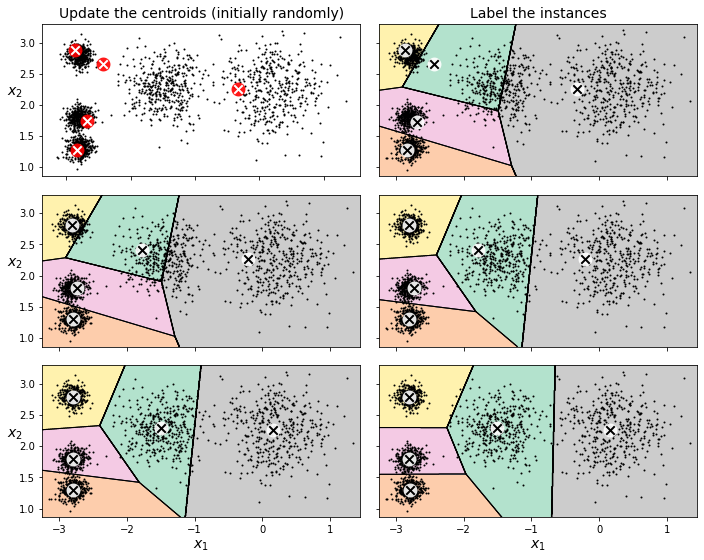

In [ ]:
# extra code – this cell generates and saves Figure 9–4

kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=1, max_iter=1,
                      random_state=5)
kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=1, max_iter=2,
                      random_state=5)
kmeans_iter3 = KMeans(n_clusters=5, init="random", n_init=1, max_iter=3,
                      random_state=5)
kmeans_iter1.fit(X)
kmeans_iter2.fit(X)
kmeans_iter3.fit(X)

plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)")

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False,
                         show_ylabels=False)
plt.title("Label the instances")

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False,
                         show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False,
                         show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

save_fig("kmeans_algorithm_plot")
plt.show()

**Tính biến động của K-Means**

Trong thuật toán **K-Trung bình** (K-Means) gốc, các **tâm cụm** (centroids) chỉ được **khởi tạo ngẫu nhiên**, và thuật toán chỉ chạy một lần **lặp** (iteration) duy nhất để dần dần cải thiện các tâm cụm, như chúng ta đã thấy ở trên.

Tuy nhiên, một vấn đề lớn với phương pháp này là nếu bạn chạy K-Means nhiều lần (hoặc với các **hạt giống ngẫu nhiên** *random seeds* khác nhau), nó có thể hội tụ đến các giải pháp **rất khác nhau**, như bạn có thể thấy dưới đây:

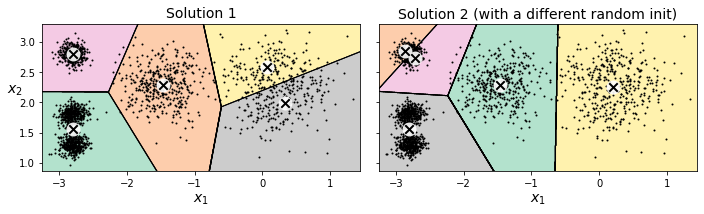

In [ ]:
# extra code – this cell generates and saves Figure 9–5

def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None,
                              title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2)

kmeans_rnd_init1 = KMeans(n_clusters=5, init="random", n_init=1, random_state=2)
kmeans_rnd_init2 = KMeans(n_clusters=5, init="random", n_init=1, random_state=9)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,
                          "Solution 1",
                          "Solution 2 (with a different random init)")

save_fig("kmeans_variability_plot")
plt.show()

In [ ]:
good_init = np.array([[-3, 3], [-3, 2], [-3, 1], [-1, 2], [0, 2]])
kmeans = KMeans(n_clusters=5, init=good_init, n_init=1, random_state=42)
kmeans.fit(X)

KMeans(init=array([[-3,  3],
       [-3,  2],
       [-3,  1],
       [-1,  2],
       [ 0,  2]]),
       n_clusters=5, n_init=1, random_state=42)

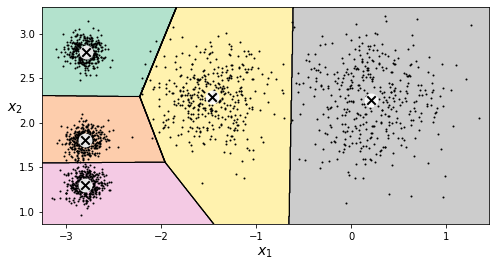

In [ ]:
# extra code
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)

### Quán tính

Để chọn **mô hình tốt nhất**, chúng ta sẽ cần một cách để đánh giá hiệu suất của mô hình **K-Trung bình** (K-Means). Thật không may, phân cụm là một nhiệm vụ **không giám sát** (unsupervised task), vì vậy chúng ta **không có các mục tiêu** (*targets*). Nhưng ít nhất, chúng ta có thể đo khoảng cách giữa mỗi thể hiện và **tâm cụm** (centroid) của nó. Đây chính là ý tưởng đằng sau số liệu **quán tính** (*inertia*):

In [ ]:
kmeans.inertia_

211.59853725816836

In [ ]:
kmeans_rnd_init1.inertia_  # extra code

219.43539442771404

In [ ]:
kmeans_rnd_init2.inertia_  # extra code

258.64724728961636

Như bạn có thể dễ dàng xác minh, **quán tính** (*inertia*) là **tổng bình phương khoảng cách** giữa mỗi **thể hiện huấn luyện** (training instance) và **tâm cụm** (centroid) gần nhất của nó:

In [ ]:
# extra code
X_dist = kmeans.transform(X)
(X_dist[np.arange(len(X_dist)), kmeans.labels_] ** 2).sum()

211.59853725816856

Phương thức `score()` trả về **quán tính** (*inertia*) **âm**. Tại sao lại là âm? À, đó là vì phương thức `score()` của một **bộ dự đoán** (*predictor*) luôn phải tuân thủ quy tắc **"càng lớn càng tốt"** (*greater is better*).

In [ ]:
kmeans.score(X)

-211.5985372581684

### Khởi tạo Đa lần

Vì vậy, một phương pháp để giải quyết vấn đề **tính biến thiên** (variability) là đơn giản là chạy thuật toán **K-Trung bình** (K-Means) nhiều lần với các **khởi tạo ngẫu nhiên** khác nhau, và chọn giải pháp giúp **giảm thiểu quán tính** (*inertia*) nhất.

Khi bạn đặt siêu tham số `n_init`, Scikit-Learn sẽ chạy thuật toán gốc `n_init` lần, và chọn giải pháp giúp **giảm thiểu quán tính** (*inertia*) nhất. Theo mặc định, Scikit-Learn đặt `n_init=10`.

In [ ]:
# extra code
kmeans_rnd_10_inits = KMeans(n_clusters=5, init="random", n_init=10,
                             random_state=2)
kmeans_rnd_10_inits.fit(X)

KMeans(init='random', n_clusters=5, random_state=2)

Như bạn có thể thấy, chúng ta kết thúc với **mô hình ban đầu**, vốn chắc chắn là **giải pháp K-Trung bình (K-Means) tối ưu** (ít nhất là về mặt **quán tính** (*inertia*), và giả định $k=5$).

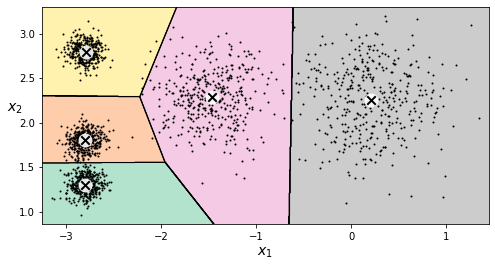

In [ ]:
# extra code
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.show()

In [ ]:
kmeans_rnd_10_inits.inertia_

211.5985372581684

### Các Phương pháp Khởi tạo Tâm cụm

Thay vì khởi tạo các **tâm cụm** (centroids) hoàn toàn ngẫu nhiên, ta nên ưu tiên khởi tạo chúng bằng thuật toán sau, được đề xuất trong một [bài báo năm 2006](https://goo.gl/eNUPw6) bởi David Arthur và Sergei Vassilvitskii:
* Lấy một tâm cụm $c_1$, được chọn **đồng nhất** (uniformly) ngẫu nhiên từ tập dữ liệu.
* Lấy một tâm mới $c_i$, chọn một **thể hiện** $\mathbf{x}_i$ với xác suất: $D(\mathbf{x}_i)^2$ / $\sum\limits_{j=1}^{m}{D(\mathbf{x}_j)}^2$ trong đó $D(\mathbf{x}_i)$ là khoảng cách giữa thể hiện $\mathbf{x}_i$ và tâm cụm gần nhất đã được chọn. Phân bố xác suất này đảm bảo rằng các thể hiện **càng xa** các tâm cụm đã chọn thì càng có nhiều khả năng được chọn làm tâm cụm.
* Lặp lại bước trước cho đến khi tất cả $k$ tâm cụm đã được chọn.

The rest of the K-Means++ algorithm is just regular K-Means. With this initialization, the K-Means algorithm is much less likely to converge to a suboptimal solution, so it is possible to reduce `n_init` considerably. Most of the time, this largely compensates for the additional complexity of the initialization process.

Để đặt phương pháp khởi tạo là **K-Means++**, chỉ cần đặt `init="k-means++"` (đây thực ra là giá trị mặc định):

### K-Trung bình Tăng tốc

Thuật toán **K-Trung bình** (K-Means) đôi khi có thể được **tăng tốc** bằng cách tránh nhiều phép tính khoảng cách không cần thiết: điều này đạt được bằng cách khai thác **bất đẳng thức tam giác** (cho ba điểm A, B và C, khoảng cách AC luôn thỏa mãn AC $\leq$ AB + BC) và bằng cách theo dõi các **cận dưới và cận trên** (lower and upper bounds) cho khoảng cách giữa các thể hiện (instances) và tâm cụm (centroids) (xem [bài báo năm 2003](https://www.aaai.org/Papers/ICML/2003/ICML03-022.pdf) này của Charles Elkan để biết thêm chi tiết).

For Elkan's variant of K-Means, use `algorithm="elkan"`. For regular KMeans, use `algorithm="full"`. The default is `"auto"`, which uses the full algorithm since Scikit-Learn 1.1 (it used Elkan's algorithm before that).

### Mini-Batch K-Means

Scikit-Learn cũng triển khai một **biến thể** của thuật toán **K-Trung bình** (K-Means) hỗ trợ **mini-batch** (xem [bài báo này](http://www.eecs.tufts.edu/~dsculley/papers/fastkmeans.pdf)):

In [ ]:
from sklearn.cluster import MiniBatchKMeans

minibatch_kmeans = MiniBatchKMeans(n_clusters=5, n_init=3, random_state=42)
minibatch_kmeans.fit(X)

MiniBatchKMeans(n_clusters=5, random_state=42)

**Lưu ý**: Xuyên suốt notebook này, khi tham số `n_init` không được đặt khi tạo một bộ ước lượng `MiniBatchKMeans`, tôi đã **tường minh** (explicitly) đặt nó thành `n_init=3` để tránh một cảnh báo về việc giá trị mặc định cho siêu tham số này sẽ thay đổi từ 3 thành `"auto"` trong Scikit-Learn phiên bản 1.4.

In [ ]:
minibatch_kmeans.inertia_

211.65239850433204

**Sử dụng `MiniBatchKMeans` cùng với `memmap`** (không có trong sách)

Nếu tập dữ liệu không vừa với bộ nhớ (memory), tùy chọn đơn giản nhất là sử dụng lớp `memmap`, giống như chúng ta đã làm với **PCA tăng dần** (*incremental PCA*) trong chương trước. Đầu tiên, hãy tải **MNIST**:

In [ ]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False, parser="auto")

Hãy phân tách tập dữ liệu:

In [ ]:
X_train, y_train = mnist.data[:60000], mnist.target[:60000]
X_test, y_test = mnist.data[60000:], mnist.target[60000:]

Tiếp theo, hãy ghi tập dữ liệu huấn luyện vào một `memmap`:

In [ ]:
filename = "my_mnist.mmap"
X_memmap = np.memmap(filename, dtype='float32', mode='write',
                     shape=X_train.shape)
X_memmap[:] = X_train
X_memmap.flush()

In [ ]:
from sklearn.cluster import MiniBatchKMeans

minibatch_kmeans = MiniBatchKMeans(n_clusters=10, batch_size=10,
                                   n_init=3, random_state=42)
minibatch_kmeans.fit(X_memmap)

MiniBatchKMeans(batch_size=10, n_clusters=10, random_state=42)

Hãy vẽ **tỷ lệ quán tính** (*inertia ratio*) và **tỷ lệ thời gian huấn luyện** (*training time ratio*) giữa **K-Trung bình Mini-batch** và **K-Trung bình thông thường**:

100/100

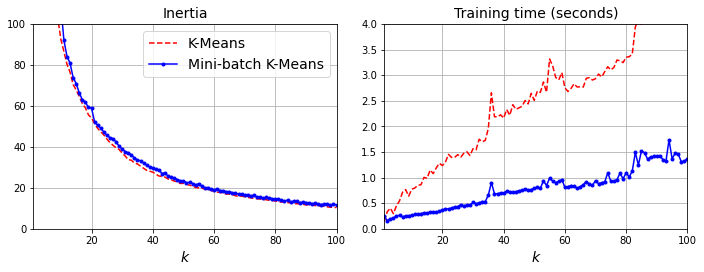

In [ ]:
# extra code – this cell generates and saves Figure 9–6

from timeit import timeit

max_k = 100
times = np.empty((max_k, 2))
inertias = np.empty((max_k, 2))
for k in range(1, max_k + 1):
    kmeans_ = KMeans(n_clusters=k, algorithm="lloyd", n_init=10, random_state=42)
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k, n_init=10, random_state=42)
    print(f"\r{k}/{max_k}", end="")  # \r returns to the start of line
    times[k - 1, 0] = timeit("kmeans_.fit(X)", number=10, globals=globals())
    times[k - 1, 1] = timeit("minibatch_kmeans.fit(X)", number=10,
                             globals=globals())
    inertias[k - 1, 0] = kmeans_.inertia_
    inertias[k - 1, 1] = minibatch_kmeans.inertia_

plt.figure(figsize=(10, 4))

plt.subplot(121)
plt.plot(range(1, max_k + 1), inertias[:, 0], "r--", label="K-Means")
plt.plot(range(1, max_k + 1), inertias[:, 1], "b.-", label="Mini-batch K-Means")
plt.xlabel("$k$")
plt.title("Inertia")
plt.legend()
plt.axis([1, max_k, 0, 100])
plt.grid()

plt.subplot(122)
plt.plot(range(1, max_k + 1), times[:, 0], "r--", label="K-Means")
plt.plot(range(1, max_k + 1), times[:, 1], "b.-", label="Mini-batch K-Means")
plt.xlabel("$k$")
plt.title("Training time (seconds)")
plt.axis([1, max_k, 0, 4])
plt.grid()

save_fig("minibatch_kmeans_vs_kmeans_plot")
plt.show()

### Tìm số lượng cụm tối ưu

Điều gì sẽ xảy ra nếu số lượng cụm được đặt thành giá trị nhỏ hơn hoặc lớn hơn 5?

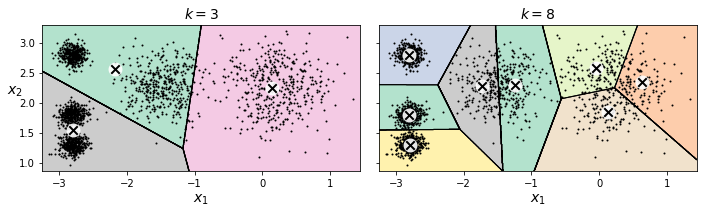

In [ ]:
# extra code – this cell generates and saves Figure 9–7

kmeans_k3 = KMeans(n_clusters=3, n_init=10, random_state=42)
kmeans_k8 = KMeans(n_clusters=8, n_init=10, random_state=42)

plot_clusterer_comparison(kmeans_k3, kmeans_k8, X, "$k=3$", "$k=8$")
save_fig("bad_n_clusters_plot")
plt.show()

Ôi, hai mô hình này trông không ổn lắm. Vậy còn **quán tính** (*inertias*) của chúng thì sao?

In [ ]:
kmeans_k3.inertia_

653.2167190021554

In [ ]:
kmeans_k8.inertia_

119.11983416102882

Không, chúng ta không thể đơn giản lấy giá trị $k$ giúp **giảm thiểu quán tính** (*inertia*) nhất, vì nó sẽ **tiếp tục giảm** khi chúng ta tăng $k$. Thật vậy, càng có nhiều cụm, mỗi **thể hiện** (instance) sẽ càng gần **tâm cụm** (centroid) gần nhất của nó, và do đó quán tính sẽ càng thấp. Tuy nhiên, chúng ta có thể vẽ **quán tính** theo hàm của $k$ và phân tích đường cong thu được:

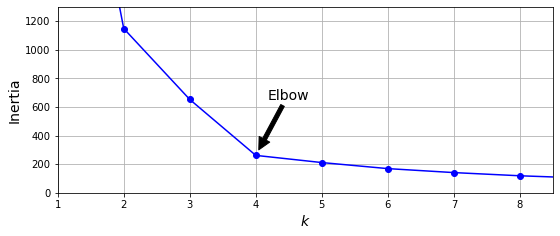

In [ ]:
# extra code – this cell generates and saves Figure 9–8

kmeans_per_k = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
                for k in range(1, 10)]
inertias = [model.inertia_ for model in kmeans_per_k]

plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 10), inertias, "bo-")
plt.xlabel("$k$")
plt.ylabel("Inertia")
plt.annotate("", xy=(4, inertias[3]), xytext=(4.45, 650),
             arrowprops=dict(facecolor='black', shrink=0.1))
plt.text(4.5, 650, "Elbow", horizontalalignment="center")
plt.axis([1, 8.5, 0, 1300])
plt.grid()
save_fig("inertia_vs_k_plot")
plt.show()

Như bạn có thể thấy, có một **cùi chỏ** (*elbow*) tại $k=4$, điều này có nghĩa là số lượng cụm ít hơn sẽ không tốt, và nhiều cụm hơn sẽ không giúp ích nhiều và có thể cắt đôi các cụm. Vì vậy, $k=4$ là một lựa chọn khá tốt. Dĩ nhiên, trong ví dụ này nó không hoàn hảo vì nó có nghĩa là hai **khối** (*blobs*) ở phía dưới bên trái sẽ chỉ được coi là một cụm duy nhất, nhưng đây dù sao cũng là một kết quả phân cụm khá tốt.

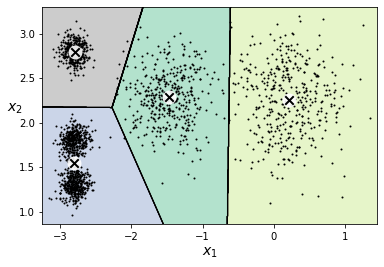

In [ ]:
# extra code
plot_decision_boundaries(kmeans_per_k[4 - 1], X)
plt.show()

Một phương pháp khác là xem xét **điểm số hình bóng** (*silhouette score*), là **hệ số hình bóng** (*silhouette coefficient*) trung bình trên tất cả các thể hiện. Hệ số hình bóng của một thể hiện bằng (_b_ - _a_) / max(_a_, _b_) trong đó _a_ là **khoảng cách trung bình** đến các thể hiện khác trong cùng một cụm (nó là **khoảng cách nội cụm trung bình** - *mean intra-cluster distance*), và _b_ là **khoảng cách trung bình đến cụm gần nhất** (*mean nearest-cluster distance*), tức là khoảng cách trung bình đến các thể hiện của cụm gần nhất tiếp theo (được xác định là cụm làm giảm thiểu _b_, loại trừ cụm của chính thể hiện đó). Hệ số hình bóng có thể thay đổi từ **-1 đến +1**: hệ số gần **+1** có nghĩa là thể hiện đó nằm rõ ràng bên trong cụm của nó và **xa** các cụm khác, trong khi hệ số gần **0** có nghĩa là nó nằm **gần ranh giới cụm**, và cuối cùng, hệ số gần **-1** có nghĩa là thể hiện đó có thể đã bị gán **nhầm cụm**.

Hãy vẽ **điểm số hình bóng** (*silhouette score*) theo hàm của $k$:

In [ ]:
from sklearn.metrics import silhouette_score

In [ ]:
silhouette_score(X, kmeans.labels_)

0.655517642572828

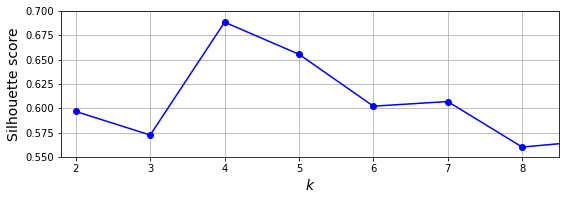

In [ ]:
# extra code – this cell generates and saves Figure 9–9

silhouette_scores = [silhouette_score(X, model.labels_)
                     for model in kmeans_per_k[1:]]

plt.figure(figsize=(8, 3))
plt.plot(range(2, 10), silhouette_scores, "bo-")
plt.xlabel("$k$")
plt.ylabel("Silhouette score")
plt.axis([1.8, 8.5, 0.55, 0.7])
plt.grid()
save_fig("silhouette_score_vs_k_plot")
plt.show()

Như bạn có thể thấy, hình ảnh trực quan này **phong phú hơn** nhiều so với hình ảnh trước: đặc biệt, mặc dù nó xác nhận rằng $k=4$ là một lựa chọn rất tốt, nhưng nó cũng nhấn mạnh một thực tế là $k=5$ cũng **khá tốt**.

Một hình ảnh trực quan thậm chí còn cung cấp nhiều thông tin hơn là khi bạn vẽ **hệ số hình bóng** (*silhouette coefficient*) của mọi thể hiện, được sắp xếp theo cụm mà chúng được gán và theo giá trị của hệ số đó. Đây được gọi là **sơ đồ hình bóng** (*silhouette diagram*):

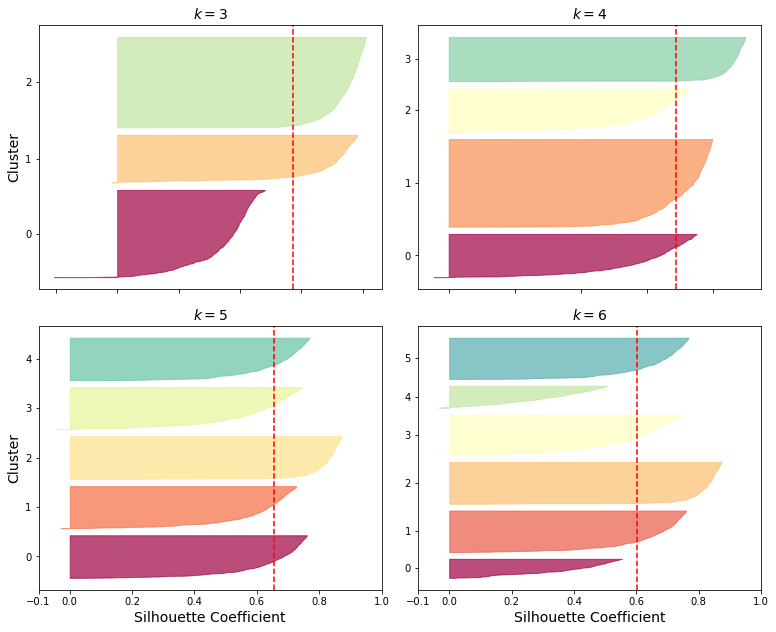

In [ ]:
# extra code – this cell generates and saves Figure 9–10

from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter

plt.figure(figsize=(11, 9))

for k in (3, 4, 5, 6):
    plt.subplot(2, 2, k - 2)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = plt.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")

    if k in (5, 6):
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    else:
        plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$")

save_fig("silhouette_analysis_plot")
plt.show()

Như bạn có thể thấy, $k=5$ trông có vẻ là **lựa chọn tốt nhất** ở đây, vì tất cả các cụm đều có **kích thước gần như nhau**, và tất cả chúng đều **vượt qua đường gạch ngang**, đại diện cho **điểm số hình bóng trung bình** (*mean silhouette score*).

## Những hạn chế của K-Means

Hãy tạo một tập dữ liệu **khó hơn**, với các **khối kéo dài** (*elongated blobs*) và **mật độ khác nhau** (*varying densities*), và cho thấy rằng **K-Trung bình** (K-Means) gặp khó khăn khi phân cụm nó một cách chính xác:

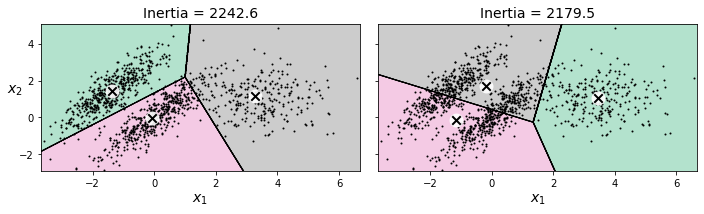

In [ ]:
# extra code – this cell generates and saves Figure 9–11

X1, y1 = make_blobs(n_samples=1000, centers=((4, -4), (0, 0)), random_state=42)
X1 = X1.dot(np.array([[0.374, 0.95], [0.732, 0.598]]))
X2, y2 = make_blobs(n_samples=250, centers=1, random_state=42)
X2 = X2 + [6, -8]
X = np.r_[X1, X2]
y = np.r_[y1, y2]

kmeans_good = KMeans(n_clusters=3,
                     init=np.array([[-1.5, 2.5], [0.5, 0], [4, 0]]),
                     n_init=1, random_state=42)
kmeans_bad = KMeans(n_clusters=3, n_init=10, random_state=42)
kmeans_good.fit(X)
kmeans_bad.fit(X)

plt.figure(figsize=(10, 3.2))

plt.subplot(121)
plot_decision_boundaries(kmeans_good, X)
plt.title(f"Inertia = {kmeans_good.inertia_:.1f}")

plt.subplot(122)
plot_decision_boundaries(kmeans_bad, X, show_ylabels=False)
plt.title(f"Inertia = {kmeans_bad.inertia_:.1f}")

save_fig("bad_kmeans_plot")
plt.show()

## Sử dụng Phân cụm cho Phân đoạn Ảnh

Tải xuống hình ảnh bọ rùa:

In [ ]:
# extra code – downloads the ladybug image

import urllib.request

homl3_root = "https://github.com/ageron/handson-ml3/raw/main/"
filename = "ladybug.png"
filepath = IMAGES_PATH / filename
if not filepath.is_file():
    print("Downloading", filename)
    url = f"{homl3_root}/images/unsupervised_learning/{filename}"
    urllib.request.urlretrieve(url, filepath)

In [ ]:
import PIL

image = np.asarray(PIL.Image.open(filepath))
image.shape

(533, 800, 3)

In [ ]:
X = image.reshape(-1, 3)
kmeans = KMeans(n_clusters=8, n_init=10, random_state=42).fit(X)
segmented_img = kmeans.cluster_centers_[kmeans.labels_]
segmented_img = segmented_img.reshape(image.shape)

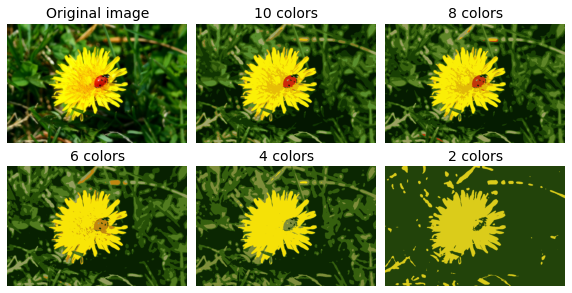

In [ ]:
# extra code – this cell generates and saves Figure 9–12

segmented_imgs = []
n_colors = (10, 8, 6, 4, 2)
for n_clusters in n_colors:
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42).fit(X)
    segmented_img = kmeans.cluster_centers_[kmeans.labels_]
    segmented_imgs.append(segmented_img.reshape(image.shape))

plt.figure(figsize=(10, 5))
plt.subplots_adjust(wspace=0.05, hspace=0.1)

plt.subplot(2, 3, 1)
plt.imshow(image)
plt.title("Original image")
plt.axis('off')

for idx, n_clusters in enumerate(n_colors):
    plt.subplot(2, 3, 2 + idx)
    plt.imshow(segmented_imgs[idx] / 255)
    plt.title(f"{n_clusters} colors")
    plt.axis('off')

save_fig('image_segmentation_plot', tight_layout=False)
plt.show()

## Sử dụng Phân cụm cho Học Bán giám sát

Một trường hợp sử dụng khác cho **phân cụm** (*clustering*) là **học bán giám sát** (*semi-supervised learning*), khi chúng ta có **rất nhiều thể hiện không được gán nhãn** (*unlabeled instances*) và **rất ít thể hiện được gán nhãn** (*labeled instances*).

Hãy giải quyết **tập dữ liệu chữ số** (*digits dataset*) vốn là một tập dữ liệu đơn giản **giống MNIST** chứa 1.797 hình ảnh **mức xám** (*grayscale*) **8×8** đại diện cho các chữ số từ 0 đến 9.

In [ ]:
from sklearn.datasets import load_digits

X_digits, y_digits = load_digits(return_X_y=True)
X_train, y_train = X_digits[:1400], y_digits[:1400]
X_test, y_test = X_digits[1400:], y_digits[1400:]

Hãy xem xét **hiệu suất** của một **mô hình hồi quy logistic** (*logistic regression model*) khi chúng ta chỉ có **50 thể hiện được gán nhãn** (*labeled instances*):

In [ ]:
from sklearn.linear_model import LogisticRegression

n_labeled = 50
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train[:n_labeled], y_train[:n_labeled])

LogisticRegression(max_iter=10000)

In [ ]:
log_reg.score(X_test, y_test)

0.7481108312342569

In [ ]:
# extra code – measure the accuracy when we use the whole training set
log_reg_full = LogisticRegression(max_iter=10_000)
log_reg_full.fit(X_train, y_train)
log_reg_full.score(X_test, y_test)

0.906801007556675

Tất nhiên, con số này **thấp hơn** nhiều so với lúc trước. Hãy xem làm thế nào chúng ta có thể làm tốt hơn. Đầu tiên, hãy **phân cụm** (*cluster*) tập huấn luyện thành **50 cụm**, sau đó đối với mỗi cụm, hãy tìm **hình ảnh gần tâm cụm nhất**. Chúng ta sẽ gọi những hình ảnh này là **hình ảnh đại diện** (*representative images*):

In [ ]:
k = 50
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
X_digits_dist = kmeans.fit_transform(X_train)
representative_digit_idx = X_digits_dist.argmin(axis=0)
X_representative_digits = X_train[representative_digit_idx]

Bây giờ chúng ta hãy vẽ các **hình ảnh đại diện** này và **gán nhãn** chúng theo cách thủ công:

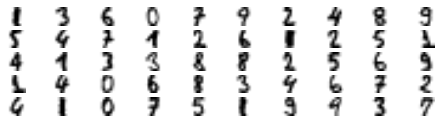

In [ ]:
# extra code – this cell generates and saves Figure 9–13

plt.figure(figsize=(8, 2))
for index, X_representative_digit in enumerate(X_representative_digits):
    plt.subplot(k // 10, 10, index + 1)
    plt.imshow(X_representative_digit.reshape(8, 8), cmap="binary",
               interpolation="bilinear")
    plt.axis('off')

save_fig("representative_images_plot", tight_layout=False)
plt.show()

In [ ]:
y_representative_digits = np.array([
    1, 3, 6, 0, 7, 9, 2, 4, 8, 9,
    5, 4, 7, 1, 2, 6, 1, 2, 5, 1,
    4, 1, 3, 3, 8, 8, 2, 5, 6, 9,
    1, 4, 0, 6, 8, 3, 4, 6, 7, 2,
    4, 1, 0, 7, 5, 1, 9, 9, 3, 7
])

Bây giờ chúng ta có một tập dữ liệu chỉ với **50 thể hiện được gán nhãn** (*labeled instances*), nhưng thay vì là các thể hiện hoàn toàn ngẫu nhiên, mỗi thể hiện trong số đó là một **hình ảnh đại diện** của cụm nó. Hãy xem liệu hiệu suất có tốt hơn không:

In [ ]:
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_representative_digits, y_representative_digits)
log_reg.score(X_test, y_test)

0.8488664987405542

**Chà!** Chúng ta đã **tăng vọt** từ độ chính xác 74.8% lên 84.9%, mặc dù chúng ta **vẫn chỉ huấn luyện mô hình trên 50 thể hiện**. Vì việc **gán nhãn** các thể hiện thường tốn kém và khó khăn, đặc biệt khi nó phải được thực hiện thủ công bởi các chuyên gia, nên đó là một ý tưởng hay để khiến họ gán nhãn cho **các thể hiện đại diện** thay vì chỉ các thể hiện ngẫu nhiên.

Nhưng có lẽ chúng ta có thể tiến thêm một bước nữa: điều gì sẽ xảy ra nếu chúng ta **lan truyền** (*propagate*) các **nhãn** (*labels*) đó đến tất cả các **thể hiện** (*instances*) khác trong cùng một cụm?

In [ ]:
y_train_propagated = np.empty(len(X_train), dtype=np.int64)
for i in range(k):
    y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i]

In [ ]:
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train, y_train_propagated)

LogisticRegression(max_iter=10000)

In [ ]:
log_reg.score(X_test, y_test)

0.8942065491183879

Chúng ta lại có thêm một **bước tăng đáng kể về độ chính xác** (*significant accuracy boost*)! Hãy xem liệu chúng ta có thể làm tốt hơn nữa bằng cách **bỏ qua 1%** các **thể hiện** (*instances*) **xa tâm cụm** (*cluster center*) nhất của chúng: điều này sẽ giúp loại bỏ một số **điểm ngoại lai** (*outliers*):

In [ ]:
percentile_closest = 99

X_cluster_dist = X_digits_dist[np.arange(len(X_train)), kmeans.labels_]
for i in range(k):
    in_cluster = (kmeans.labels_ == i)
    cluster_dist = X_cluster_dist[in_cluster]
    cutoff_distance = np.percentile(cluster_dist, percentile_closest)
    above_cutoff = (X_cluster_dist > cutoff_distance)
    X_cluster_dist[in_cluster & above_cutoff] = -1

partially_propagated = (X_cluster_dist != -1)
X_train_partially_propagated = X_train[partially_propagated]
y_train_partially_propagated = y_train_propagated[partially_propagated]

In [ ]:
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train_partially_propagated, y_train_partially_propagated)
log_reg.score(X_test, y_test)

0.9093198992443325

**Chà**, lại thêm một **bước tăng về độ chính xác** (*accuracy boost*) nữa! Chúng ta thậm chí đã **vượt qua** một chút hiệu suất mà chúng ta có được khi **huấn luyện trên tập huấn luyện được gán nhãn đầy đủ** (*fully labeled training set*)!

Các **nhãn được lan truyền** (*propagated labels*) của chúng ta thực sự khá tốt: độ chính xác của chúng là khoảng 97.6%:

In [ ]:
(y_train_partially_propagated == y_train[partially_propagated]).mean()

0.9755555555555555

Bây giờ bạn có thể thực hiện một vài lần **lặp** của **học tập tích cực** (*active learning*):
1. **Gán nhãn thủ công** các **thể hiện** (*instances*) mà bộ phân loại **ít chắc chắn nhất** (least sure about), nếu có thể, bằng cách chọn chúng trong các cụm khác nhau.
2. Huấn luyện một **mô hình mới** với các nhãn bổ sung này.

## DBSCAN

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=1000, noise=0.05, random_state=42)
dbscan = DBSCAN(eps=0.05, min_samples=5)
dbscan.fit(X)

DBSCAN(eps=0.05)

In [ ]:
dbscan.labels_[:10]

array([ 0,  2, -1, -1,  1,  0,  0,  0,  2,  5])

In [ ]:
dbscan.core_sample_indices_[:10]

array([ 0,  4,  5,  6,  7,  8, 10, 11, 12, 13])

In [ ]:
dbscan.components_

array([[-0.02137124,  0.40618608],
       [-0.84192557,  0.53058695],
       [ 0.58930337, -0.32137599],
       ...,
       [ 1.66258462, -0.3079193 ],
       [-0.94355873,  0.3278936 ],
       [ 0.79419406,  0.60777171]])

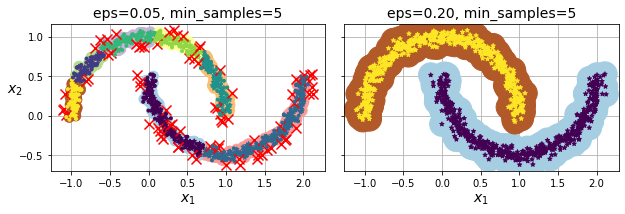

In [ ]:
# extra code – this cell generates and saves Figure 9–14

def plot_dbscan(dbscan, X, size, show_xlabels=True, show_ylabels=True):
    core_mask = np.zeros_like(dbscan.labels_, dtype=bool)
    core_mask[dbscan.core_sample_indices_] = True
    anomalies_mask = dbscan.labels_ == -1
    non_core_mask = ~(core_mask | anomalies_mask)

    cores = dbscan.components_
    anomalies = X[anomalies_mask]
    non_cores = X[non_core_mask]

    plt.scatter(cores[:, 0], cores[:, 1],
                c=dbscan.labels_[core_mask], marker='o', s=size, cmap="Paired")
    plt.scatter(cores[:, 0], cores[:, 1], marker='*', s=20,
                c=dbscan.labels_[core_mask])
    plt.scatter(anomalies[:, 0], anomalies[:, 1],
                c="r", marker="x", s=100)
    plt.scatter(non_cores[:, 0], non_cores[:, 1],
                c=dbscan.labels_[non_core_mask], marker=".")
    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)
    plt.title(f"eps={dbscan.eps:.2f}, min_samples={dbscan.min_samples}")
    plt.grid()
    plt.gca().set_axisbelow(True)

dbscan2 = DBSCAN(eps=0.2)
dbscan2.fit(X)

plt.figure(figsize=(9, 3.2))

plt.subplot(121)
plot_dbscan(dbscan, X, size=100)

plt.subplot(122)
plot_dbscan(dbscan2, X, size=600, show_ylabels=False)

save_fig("dbscan_plot")
plt.show()

In [ ]:
dbscan = dbscan2  # extra code – the text says we now use eps=0.2

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])

KNeighborsClassifier(n_neighbors=50)

In [ ]:
X_new = np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2, 1]])
knn.predict(X_new)

array([1, 0, 1, 0])

In [ ]:
knn.predict_proba(X_new)

array([[0.18, 0.82],
       [1.  , 0.  ],
       [0.12, 0.88],
       [1.  , 0.  ]])

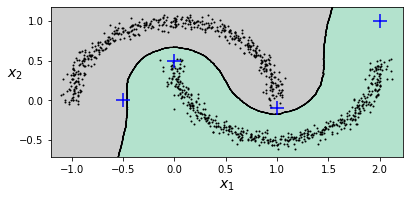

In [ ]:
# extra code – this cell generates and saves Figure 9–15

plt.figure(figsize=(6, 3))
plot_decision_boundaries(knn, X, show_centroids=False)
plt.scatter(X_new[:, 0], X_new[:, 1], c="b", marker="+", s=200, zorder=10)
save_fig("cluster_classification_plot")
plt.show()

In [ ]:
y_dist, y_pred_idx = knn.kneighbors(X_new, n_neighbors=1)
y_pred = dbscan.labels_[dbscan.core_sample_indices_][y_pred_idx]
y_pred[y_dist > 0.2] = -1
y_pred.ravel()

array([-1,  0,  1, -1])

## Các Thuật toán Phân cụm Khác

Mã trong phần này là **tài liệu bổ sung**, **không có trong sách**.

### Phân cụm Phổ

In [ ]:
from sklearn.cluster import SpectralClustering

In [ ]:
sc1 = SpectralClustering(n_clusters=2, gamma=100, random_state=42)
sc1.fit(X)

SpectralClustering(gamma=100, n_clusters=2, random_state=42)

In [ ]:
sc1.affinity_matrix_.round(2)

array([[1. , 0. , 0. , ..., 0. , 0. , 0. ],
       [0. , 1. , 0.3, ..., 0. , 0. , 0. ],
       [0. , 0.3, 1. , ..., 0. , 0. , 0. ],
       ...,
       [0. , 0. , 0. , ..., 1. , 0. , 0. ],
       [0. , 0. , 0. , ..., 0. , 1. , 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 1. ]])

In [ ]:
sc2 = SpectralClustering(n_clusters=2, gamma=1, random_state=42)
sc2.fit(X)

SpectralClustering(gamma=1, n_clusters=2, random_state=42)

In [ ]:
def plot_spectral_clustering(sc, X, size, alpha, show_xlabels=True,
                             show_ylabels=True):
    plt.scatter(X[:, 0], X[:, 1], marker='o', s=size, c='gray', alpha=alpha)
    plt.scatter(X[:, 0], X[:, 1], marker='o', s=30, c='w')
    plt.scatter(X[:, 0], X[:, 1], marker='.', s=10, c=sc.labels_, cmap="Paired")

    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)
    plt.title(f"RBF gamma={sc.gamma}")

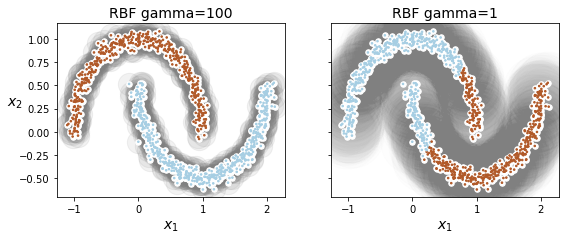

In [ ]:
plt.figure(figsize=(9, 3.2))

plt.subplot(121)
plot_spectral_clustering(sc1, X, size=500, alpha=0.1)

plt.subplot(122)
plot_spectral_clustering(sc2, X, size=4000, alpha=0.01, show_ylabels=False)

plt.show()

### Phân cụm Kết tụ

In [ ]:
from sklearn.cluster import AgglomerativeClustering

In [ ]:
X = np.array([0, 2, 5, 8.5]).reshape(-1, 1)
agg = AgglomerativeClustering(linkage="complete").fit(X)

In [ ]:
def learned_parameters(estimator):
    return [attrib for attrib in dir(estimator)
            if attrib.endswith("_") and not attrib.startswith("_")]

In [ ]:
learned_parameters(agg)

['children_',
 'labels_',
 'n_clusters_',
 'n_connected_components_',
 'n_features_in_',
 'n_leaves_']

In [ ]:
agg.children_

array([[0, 1],
       [2, 3],
       [4, 5]])

# Hỗn hợp Gaussian

Hãy tạo cùng một tập dữ liệu như trước với ba **hình elip** (*ellipsoids*) (tập dữ liệu mà **K-Trung bình** *K-Means* đã gặp khó khăn):

In [ ]:
X1, y1 = make_blobs(n_samples=1000, centers=((4, -4), (0, 0)), random_state=42)
X1 = X1.dot(np.array([[0.374, 0.95], [0.732, 0.598]]))
X2, y2 = make_blobs(n_samples=250, centers=1, random_state=42)
X2 = X2 + [6, -8]
X = np.r_[X1, X2]
y = np.r_[y1, y2]

Hãy huấn luyện một **mô hình hỗn hợp Gaussian** (*Gaussian mixture model*) trên tập dữ liệu trước đó:

In [ ]:
from sklearn.mixture import GaussianMixture

In [ ]:
gm = GaussianMixture(n_components=3, n_init=10, random_state=42)
gm.fit(X)

GaussianMixture(n_components=3, n_init=10, random_state=42)

Hãy xem xét các **tham số** (*parameters*) mà thuật toán **EM** đã ước tính:

In [ ]:
gm.weights_

array([0.39025715, 0.40007391, 0.20966893])

In [ ]:
gm.means_

array([[ 0.05131611,  0.07521837],
       [-1.40763156,  1.42708225],
       [ 3.39893794,  1.05928897]])

In [ ]:
gm.covariances_

array([[[ 0.68799922,  0.79606357],
        [ 0.79606357,  1.21236106]],

       [[ 0.63479409,  0.72970799],
        [ 0.72970799,  1.1610351 ]],

       [[ 1.14833585, -0.03256179],
        [-0.03256179,  0.95490931]]])

Thuật toán đã hội tụ chưa?

In [ ]:
gm.converged_

True

Vâng, tốt. Nó đã mất bao nhiêu lần lặp?

In [ ]:
gm.n_iter_

4

Bây giờ bạn có thể sử dụng mô hình để **dự đoán cụm** mà mỗi **thể hiện** (*instance*) thuộc về (**phân cụm cứng** - *hard clustering*) hoặc **xác suất** nó đến từ mỗi cụm. Để làm điều này, chỉ cần sử dụng phương thức `predict()` hoặc phương thức

In [ ]:
gm.predict(X)

array([0, 0, 1, ..., 2, 2, 2])

In [ ]:
gm.predict_proba(X).round(3)

array([[0.977, 0.   , 0.023],
       [0.983, 0.001, 0.016],
       [0.   , 1.   , 0.   ],
       ...,
       [0.   , 0.   , 1.   ],
       [0.   , 0.   , 1.   ],
       [0.   , 0.   , 1.   ]])

Đây là một **mô hình sinh** (*generative model*), vì vậy bạn có thể **lấy mẫu** (*sample*) các **thể hiện mới** (*new instances*) từ nó (và lấy **nhãn** của chúng):

In [ ]:
X_new, y_new = gm.sample(6)
X_new

array([[-0.86944074, -0.32767626],
       [ 0.29836051,  0.28297011],
       [-2.8014927 , -0.09047309],
       [ 3.98203732,  1.49951491],
       [ 3.81677148,  0.53095244],
       [ 2.84104923, -0.73858639]])

In [ ]:
y_new

array([0, 0, 1, 2, 2, 2])

Lưu ý rằng chúng được lấy mẫu tuần tự (sequentially) từ mỗi cụm.

Bạn cũng có thể ước tính **log** của **hàm mật độ xác suất** (*probability density function - PDF*) tại bất kỳ vị trí nào bằng cách sử dụng phương thức `score_samples()`:

In [ ]:
gm.score_samples(X).round(2)

array([-2.61, -3.57, -3.33, ..., -3.51, -4.4 , -3.81])

Hãy kiểm tra xem **Hàm mật độ xác suất** (*PDF*) có **tích phân** (*integrates*) bằng **1** trên toàn bộ không gian hay không. Chúng ta chỉ cần lấy một hình vuông lớn bao quanh các cụm, và chia nó thành một lưới các hình vuông nhỏ, sau đó chúng ta tính **xác suất xấp xỉ** (*approximate probability*) mà các thể hiện sẽ được sinh ra trong mỗi hình vuông nhỏ (bằng cách nhân **PDF** tại một góc của hình vuông nhỏ với **diện tích** của hình vuông đó), và cuối cùng **tổng hợp** (*summing*) tất cả các xác suất này. Kết quả rất **gần với 1**:

In [ ]:
# extra code – bonus material

resolution = 100
grid = np.arange(-10, 10, 1 / resolution)
xx, yy = np.meshgrid(grid, grid)
X_full = np.vstack([xx.ravel(), yy.ravel()]).T

pdf = np.exp(gm.score_samples(X_full))
pdf_probas = pdf * (1 / resolution) ** 2
pdf_probas.sum()

0.9999999999215021

Bây giờ chúng ta hãy vẽ **ranh giới quyết định** (*decision boundaries*) thu được (các đường gạch ngang) và **đường đồng mức mật độ** (*density contours*):

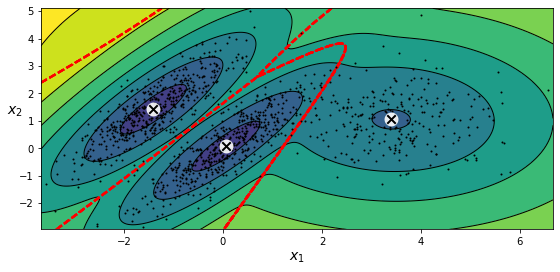

In [ ]:
# extra code – this cells generates and saves Figure 9–16

from matplotlib.colors import LogNorm

def plot_gaussian_mixture(clusterer, X, resolution=1000, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = -clusterer.score_samples(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z,
                 norm=LogNorm(vmin=1.0, vmax=30.0),
                 levels=np.logspace(0, 2, 12))
    plt.contour(xx, yy, Z,
                norm=LogNorm(vmin=1.0, vmax=30.0),
                levels=np.logspace(0, 2, 12),
                linewidths=1, colors='k')

    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z,
                linewidths=2, colors='r', linestyles='dashed')

    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)
    plot_centroids(clusterer.means_, clusterer.weights_)

    plt.xlabel("$x_1$")
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)

plt.figure(figsize=(8, 4))

plot_gaussian_mixture(gm, X)

save_fig("gaussian_mixtures_plot")
plt.show()

Bạn có thể **áp đặt các ràng buộc** lên các **ma trận hiệp phương sai** (*covariance matrices*) mà thuật toán tìm kiếm bằng cách đặt siêu tham số `covariance_type`:
* `"spherical"`: tất cả các cụm phải **có dạng hình cầu**, nhưng chúng có thể có các đường kính khác nhau (tức là **phương sai** khác nhau).
* `"diag"`: các cụm có thể mang bất kỳ **hình elip** nào với bất kỳ kích thước nào, nhưng các trục của hình elip phải **song song với các trục tọa độ** (tức là các **ma trận hiệp phương sai phải là ma trận đường chéo**).
* `"tied"`: tất cả các cụm phải có **cùng hình dạng**, vốn có thể là bất kỳ hình elip nào (tức là tất cả chúng **chia sẻ chung một ma trận hiệp phương sai**).
* `"full"` (mặc định): **không có ràng buộc**, tất cả các cụm có thể mang bất kỳ hình elip nào với bất kỳ kích thước nào.

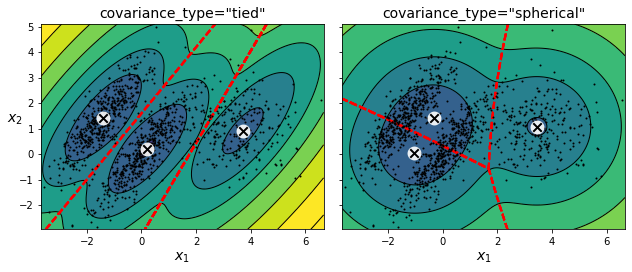

In [ ]:
# extra code – this cell generates and saves Figure 9–17

gm_full = GaussianMixture(n_components=3, n_init=10,
                          covariance_type="full", random_state=42)
gm_tied = GaussianMixture(n_components=3, n_init=10,
                          covariance_type="tied", random_state=42)
gm_spherical = GaussianMixture(n_components=3, n_init=10,
                               covariance_type="spherical", random_state=42)
gm_diag = GaussianMixture(n_components=3, n_init=10,
                          covariance_type="diag", random_state=42)
gm_full.fit(X)
gm_tied.fit(X)
gm_spherical.fit(X)
gm_diag.fit(X)

def compare_gaussian_mixtures(gm1, gm2, X):
    plt.figure(figsize=(9, 4))

    plt.subplot(121)
    plot_gaussian_mixture(gm1, X)
    plt.title(f'covariance_type="{gm1.covariance_type}"')

    plt.subplot(122)
    plot_gaussian_mixture(gm2, X, show_ylabels=False)
    plt.title(f'covariance_type="{gm2.covariance_type}"')

compare_gaussian_mixtures(gm_tied, gm_spherical, X)

save_fig("covariance_type_plot")
plt.show()

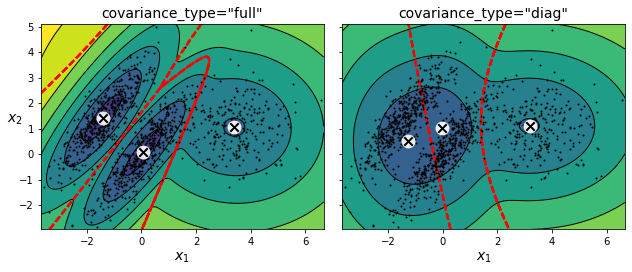

In [ ]:
# extra code – comparing covariance_type="full" and covariance_type="diag"
compare_gaussian_mixtures(gm_full, gm_diag, X)
plt.tight_layout()
plt.show()

## Phát hiện Bất thường bằng cách sử dụng Hỗn hợp Gaussian

**Hỗn hợp Gaussian** (*Gaussian Mixtures*) có thể được sử dụng cho **phát hiện bất thường** (*anomaly detection*): các **thể hiện** (*instances*) nằm ở các vùng có **mật độ thấp** (*low-density regions*) có thể được coi là **bất thường** (*anomalies*). Bạn phải xác định **ngưỡng mật độ** (*density threshold*) mà bạn muốn sử dụng. Ví dụ: trong một công ty sản xuất cố gắng phát hiện các sản phẩm lỗi, tỷ lệ sản phẩm lỗi thường được biết rõ. Giả sử tỷ lệ đó bằng **2%**, thì bạn có thể đặt ngưỡng mật độ là giá trị dẫn đến việc có **2%** số thể hiện nằm trong các khu vực **dưới ngưỡng mật độ đó**:

In [ ]:
densities = gm.score_samples(X)
density_threshold = np.percentile(densities, 2)
anomalies = X[densities < density_threshold]

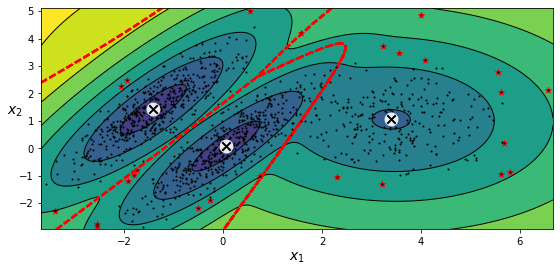

In [ ]:
# extra code – this cell generates and saves Figure 9–18

plt.figure(figsize=(8, 4))

plot_gaussian_mixture(gm, X)
plt.scatter(anomalies[:, 0], anomalies[:, 1], color='r', marker='*')
plt.ylim(top=5.1)

save_fig("mixture_anomaly_detection_plot")
plt.show()

## Chọn Số lượng Cụm

Chúng ta **không thể sử dụng quán tính** (*inertia*) hay **điểm số hình bóng** (*silhouette score*) vì cả hai đều giả định rằng các cụm có **dạng hình cầu** (*spherical*). Thay vào đó, chúng ta có thể cố gắng tìm mô hình **giảm thiểu** (*minimizes*) một tiêu chí thông tin lý thuyết như **Tiêu chí Thông tin Bayesian** (*Bayesian Information Criterion - BIC*) hoặc **Tiêu chí Thông tin Akaike** (*Akaike Information Criterion - AIC*):

$${BIC} = {\log(m)p - 2\log({\hat L})}$$

$${AIC} = 2p - 2\log(\hat L)$$

* $m$ là số lượng **thể hiện** (*instances*).
* $p$ là số lượng **tham số** (*parameters*) được mô hình học.
* $\hat L$ là giá trị **cực đại** (*maximized value*) của **hàm khả năng hợp lý** (*likelihood function*) của mô hình. Đây là **xác suất có điều kiện** (*conditional probability*) của dữ liệu quan sát được $\mathbf{X}$, với mô hình và các tham số đã được tối ưu hóa của nó.

Cả **BIC** và **AIC** đều **phạt** (*penalize*) các mô hình có nhiều tham số để học (ví dụ: nhiều cụm hơn) và **thưởng** (*reward*) cho các mô hình khớp dữ liệu tốt (tức là các mô hình cung cấp **khả năng hợp lý cao** *high likelihood* cho dữ liệu quan sát được).

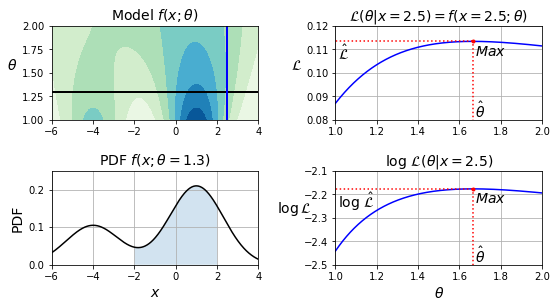

In [ ]:
# extra code – this cell generates and saves Figure 9–19

from scipy.stats import norm

x_val = 2.5
std_val = 1.3
x_range = [-6, 4]
x_proba_range = [-2, 2]
stds_range = [1, 2]

xs = np.linspace(x_range[0], x_range[1], 501)
stds = np.linspace(stds_range[0], stds_range[1], 501)
Xs, Stds = np.meshgrid(xs, stds)
Z = 2 * norm.pdf(Xs - 1.0, 0, Stds) + norm.pdf(Xs + 4.0, 0, Stds)
Z = Z / Z.sum(axis=1)[:, np.newaxis] / (xs[1] - xs[0])

x_example_idx = (xs >= x_val).argmax()  # index of the first value >= x_val
max_idx = Z[:, x_example_idx].argmax()
max_val = Z[:, x_example_idx].max()
s_example_idx = (stds >= std_val).argmax()
x_range_min_idx = (xs >= x_proba_range[0]).argmax()
x_range_max_idx = (xs >= x_proba_range[1]).argmax()
log_max_idx = np.log(Z[:, x_example_idx]).argmax()
log_max_val = np.log(Z[:, x_example_idx]).max()

plt.figure(figsize=(8, 4.5))

plt.subplot(2, 2, 1)
plt.contourf(Xs, Stds, Z, cmap="GnBu")
plt.plot([-6, 4], [std_val, std_val], "k-", linewidth=2)
plt.plot([x_val, x_val], [1, 2], "b-", linewidth=2)
plt.ylabel(r"$\theta$", rotation=0, labelpad=10)
plt.title(r"Model $f(x; \theta)$")

plt.subplot(2, 2, 2)
plt.plot(stds, Z[:, x_example_idx], "b-")
plt.plot(stds[max_idx], max_val, "r.")
plt.plot([stds[max_idx], stds[max_idx]], [0, max_val], "r:")
plt.plot([0, stds[max_idx]], [max_val, max_val], "r:")
plt.text(stds[max_idx]+ 0.01, 0.081, r"$\hat{\theta}$")
plt.text(stds[max_idx]+ 0.01, max_val - 0.006, r"$Max$")
plt.text(1.01, max_val - 0.008, r"$\hat{\mathcal{L}}$")
plt.ylabel(r"$\mathcal{L}$", rotation=0, labelpad=10)
plt.title(fr"$\mathcal{{L}}(\theta|x={x_val}) = f(x={x_val}; \theta)$")
plt.grid()
plt.axis([1, 2, 0.08, 0.12])

plt.subplot(2, 2, 3)
plt.plot(xs, Z[s_example_idx], "k-")
plt.fill_between(xs[x_range_min_idx:x_range_max_idx+1],
                 Z[s_example_idx, x_range_min_idx:x_range_max_idx+1], alpha=0.2)
plt.xlabel(r"$x$")
plt.ylabel("PDF")
plt.title(fr"PDF $f(x; \theta={std_val})$")
plt.grid()
plt.axis([-6, 4, 0, 0.25])

plt.subplot(2, 2, 4)
plt.plot(stds, np.log(Z[:, x_example_idx]), "b-")
plt.plot(stds[log_max_idx], log_max_val, "r.")
plt.plot([stds[log_max_idx], stds[log_max_idx]], [-5, log_max_val], "r:")
plt.plot([0, stds[log_max_idx]], [log_max_val, log_max_val], "r:")
plt.text(stds[log_max_idx]+ 0.01, log_max_val - 0.06, r"$Max$")
plt.text(stds[log_max_idx]+ 0.01, -2.49, r"$\hat{\theta}$")
plt.text(1.01, log_max_val - 0.08, r"$\log \, \hat{\mathcal{L}}$")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\log\mathcal{L}$", rotation=0, labelpad=10)
plt.title(fr"$\log \, \mathcal{{L}}(\theta|x={x_val})$")
plt.grid()
plt.axis([1, 2, -2.5, -2.1])

save_fig("likelihood_function_plot")
plt.show()

In [ ]:
gm.bic(X)

8189.747000497186

In [ ]:
gm.aic(X)

8102.521720382148

Chúng ta có thể tính toán **BIC** (*Bayesian Information Criterion*) theo cách thủ công như sau:

In [ ]:
# extra code – bonus material
n_clusters = 3
n_dims = 2
n_params_for_weights = n_clusters - 1
n_params_for_means = n_clusters * n_dims
n_params_for_covariance = n_clusters * n_dims * (n_dims + 1) // 2
n_params = n_params_for_weights + n_params_for_means + n_params_for_covariance
max_log_likelihood = gm.score(X) * len(X) # log(L^)
bic = np.log(len(X)) * n_params - 2 * max_log_likelihood
aic = 2 * n_params - 2 * max_log_likelihood
print(f"bic = {bic}")
print(f"aic = {aic}")
print(f"n_params = {n_params}")

bic = 8189.747000497186
aic = 8102.521720382148
n_params = 17


Có **một trọng số** (*weight*) cho mỗi cụm, nhưng tổng của chúng phải bằng 1, vì vậy chúng ta có **một bậc tự do** (*degree of freedom*) ít hơn, do đó là **-1**. Tương tự, **bậc tự do** cho một **ma trận hiệp phương sai** (*covariance matrix*) $n \times n$ không phải là $n^2$, mà là $1 + 2 + \dots + n = \dfrac{n (n+1)}{2}$.

Hãy huấn luyện các **mô hình Hỗn hợp Gaussian** (*Gaussian Mixture models*) với các giá trị $k$ khác nhau và **đo lường** (*measure*) **BIC** (*Bayesian Information Criterion*) của chúng:

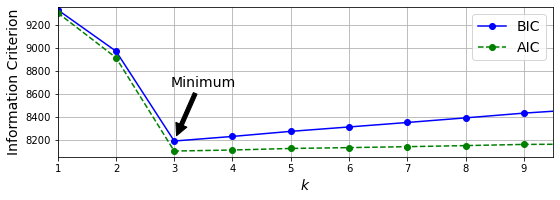

In [ ]:
# extra code – this cell generates and saves Figure 9–20

gms_per_k = [GaussianMixture(n_components=k, n_init=10, random_state=42).fit(X)
             for k in range(1, 11)]
bics = [model.bic(X) for model in gms_per_k]
aics = [model.aic(X) for model in gms_per_k]

plt.figure(figsize=(8, 3))
plt.plot(range(1, 11), bics, "bo-", label="BIC")
plt.plot(range(1, 11), aics, "go--", label="AIC")
plt.xlabel("$k$")
plt.ylabel("Information Criterion")
plt.axis([1, 9.5, min(aics) - 50, max(aics) + 50])
plt.annotate("", xy=(3, bics[2]), xytext=(3.4, 8650),
             arrowprops=dict(facecolor='black', shrink=0.1))
plt.text(3.5, 8660, "Minimum", horizontalalignment="center")
plt.legend()
plt.grid()
save_fig("aic_bic_vs_k_plot")
plt.show()

## Mô hình Hỗn hợp Gaussian Bayes

Thay vì tự mình tìm kiếm **số lượng cụm tối ưu** (*optimal number of clusters*), ta có thể sử dụng lớp `BayesianGaussianMixture` vốn có khả năng đặt các **trọng số** (*weights*) bằng (hoặc gần) không cho các cụm **không cần thiết**. Chỉ cần đặt **số lượng thành phần** (*number of components*) thành một giá trị mà bạn tin rằng **lớn hơn** số lượng cụm tối ưu, và thuật toán sẽ tự động loại bỏ các cụm không cần thiết.

In [ ]:
from sklearn.mixture import BayesianGaussianMixture

bgm = BayesianGaussianMixture(n_components=10, n_init=10, random_state=42)
bgm.fit(X)
bgm.weights_.round(2)

array([0.4 , 0.21, 0.4 , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ])

Thuật toán đã **tự động phát hiện** rằng chỉ **3 thành phần** (*components*) là cần thiết!

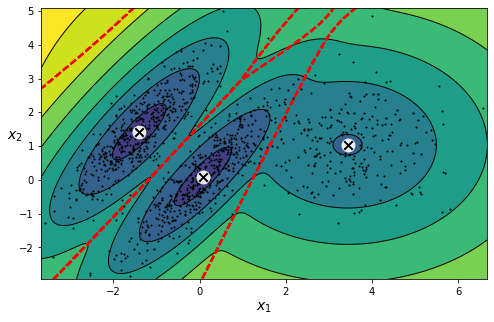

In [ ]:
# extra code – this figure is almost identical to Figure 9–16
plt.figure(figsize=(8, 5))
plot_gaussian_mixture(bgm, X)
plt.show()

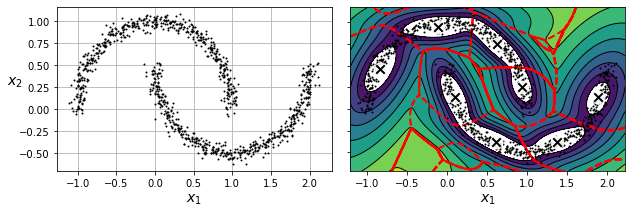

In [ ]:
# extra code – this cell generates and saves Figure 9–21

X_moons, y_moons = make_moons(n_samples=1000, noise=0.05, random_state=42)

bgm = BayesianGaussianMixture(n_components=10, n_init=10, random_state=42)
bgm.fit(X_moons)

plt.figure(figsize=(9, 3.2))

plt.subplot(121)
plot_data(X_moons)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$", rotation=0)
plt.grid()

plt.subplot(122)
plot_gaussian_mixture(bgm, X_moons, show_ylabels=False)

save_fig("moons_vs_bgm_plot")
plt.show()

**Ối, không ổn...** thay vì phát hiện **2 cụm hình mặt trăng**, thuật toán đã phát hiện **8 cụm hình elip**. Tuy nhiên, **biểu đồ mật độ** (*density plot*) trông không quá tệ, vì vậy nó có thể sử dụng được cho **phát hiện bất thường** (*anomaly detection*).

# Bài tập

<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 1: ### 🧠 Phân tích & Lập luận (Chain of Thought)</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">Để giải quyết yêu cầu của bạn về các bài tập thuộc **Chương 9: Các kỹ thuật học không giám sát**, tôi tiến hành phân tích hệ thống bài tập dựa trên các nguồn tài liệu của giáo trình:</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 2: **Kế hoạch phân chia nội dung**:
   - Do 3 bài tập lập trình (10, 11, 12) rất dài, yêu cầu thiết kế pipeline, tối ưu hóa siêu tham số và viết mã Python chi tiết, tôi sẽ thực hiện đúng chỉ dẫn của bạn: **Chia làm 2 phần**.
     - **Phần 1 (Lượt này)**: Cung cấp **danh sách đầy đủ của 12 bài tập Chương 9**, sau đó phân tích sâu sắc và trình bày lời giải chi tiết cho **từ Câu 1 đến Câu 9** [cite: 666, 667].
     - **Phần 2 (Lượt sau)**: Tập trung giải quyết trọn vẹn phần thực hành lập trình từ **Câu 10 đến Câu 12** kèm theo các đoạn mã Python tối ưu và phân tích kết quả thực nghiệm cụ thể [cite: 668, 669, 670].</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">---</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 3: Bạn sẽ định nghĩa phân cụm như thế nào? Bạn có thể kể tên một vài thuật toán phân cụm không? [cite: 666]
2. Một số ứng dụng chính của thuật toán phân cụm là gì? [cite: 667]
3. Mô tả hai kỹ thuật để chọn số lượng cụm phù hợp khi sử dụng k-means. [cite: 666]
4. Truyền nhãn (label propagation) là gì? Tại sao bạn lại triển khai nó, và bằng cách nào? [cite: 667]
5. Bạn có thể kể tên hai thuật toán phân cụm có thể mở rộng cho các tập dữ liệu lớn không? Và hai thuật toán tìm kiếm các vùng mật độ cao? [cite: 667]
6. Bạn có thể nghĩ ra một trường hợp sử dụng nào mà học tích cực (active learning) sẽ hữu ích không? Bạn sẽ triển khai nó như thế nào? [cite: 667]
7. Sự khác biệt giữa phát hiện dị thường (anomaly detection) và phát hiện điểm mới (novelty detection) là gì? [cite: 667]
8. Hỗn hợp Gaussian (Gaussian Mixture) là gì? Bạn có thể sử dụng nó cho những tác vụ nào? [cite: 667]
9. Bạn có thể kể tên hai kỹ thuật để tìm số lượng cụm phù hợp khi sử dụng mô hình hỗn hợp Gaussian không? [cite: 667]
10. **Bài tập thực hành 10**: Thiết lập hệ thống phân loại khuôn mặt trên tập dữ liệu Olivetti, sử dụng K-Means làm công cụ giảm chiều dữ liệu [cite: 668].
11. **Bài tập thực hành 11**: Huấn luyện mô hình hỗn hợp Gaussian trên tập Olivetti để sinh khuôn mặt mới và phát hiện ảnh dị thường [cite: 669].
12. **Bài tập thực hành 12**: Ứng dụng kỹ thuật giảm chiều dữ liệu PCA trên tập Olivetti để phát hiện dị thường dựa trên sai số tái tạo [cite: 670].</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">---</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 4: #### **Câu 1: Bạn sẽ định nghĩa phân cụm như thế nào? Bạn có thể kể tên một vài thuật toán phân cụm không?**
*   **Lời giải chi tiết**: 
    *   **Định nghĩa**: Trong học máy, **phân cụm (clustering)** là một tác vụ không giám sát nhằm mục đích nhóm các thể hiện (instances) tương tự nhau vào các nhóm riêng biệt gọi là các **cụm** [cite: 108, 628]. Tiêu chí đánh giá sự tương đồng phụ thuộc vào từng bài toán cụ thể: có trường hợp các điểm ở gần nhau trong không gian đặc trưng được coi là tương tự, nhưng trong các trường hợp khác, các điểm nằm cách xa nhau vẫn có thể tương tự nếu chúng thuộc cùng một cấu trúc nhóm được đóng gói dày đặc [cite: 108].
    *   **Một số thuật toán phân cụm phổ biến**: K-Trung bình (K-Means), DBSCAN, phân cụm kết tụ (agglomerative clustering), BIRCH, Dịch chuyển Trung bình (Mean-Shift), lan truyền quan hệ (affinity propagation), và phân cụm phổ (spectral clustering) [cite: 108, 634].</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">#### **Câu 2: Một số ứng dụng chính của thuật toán phân cụm là gì?**
*   **Lời giải chi tiết**: 
    Phân cụm là một công cụ đa năng được ứng dụng rộng rãi trong nhiều lĩnh vực thực tế [cite: 628]:
    1.  **Phân đoạn khách hàng (customer segmentation)**: Nhóm khách hàng dựa trên hành vi tiêu dùng và lịch sử mua sắm để thiết kế các chiến dịch tiếp thị cá nhân hóa hoặc xây dựng hệ thống đề xuất [cite: 628, 631].
    2.  **Phân tích dữ liệu**: Chạy thuật toán phân cụm để tự động gom nhóm và phân tích độc lập các phân khúc đặc trưng trong tập dữ liệu mới [cite: 632].
    3.  **Giảm chiều dữ liệu (dimensionality reduction)**: Thay thế vector đặc trưng nhiều chiều ban đầu bằng vector đo độ tương đồng của thể hiện đó đối với từng cụm dữ liệu [cite: 632].
    4.  **Học bán giám sát (semisupervised learning)**: Gán nhãn cho một số ít mẫu đại diện rồi lan truyền nhãn đó ra toàn cụm dữ liệu để tạo tập huấn luyện lớn cho thuật toán học có giám sát [cite: 633].
    5.  **Công cụ tìm kiếm**: Tìm kiếm các hình ảnh tương tự với một hình ảnh tham chiếu bằng cách truy xuất các mẫu nằm chung cụm [cite: 633].
    6.  **Phân đoạn ảnh (image segmentation)**: Phân cụm các pixel theo màu sắc để giảm số lượng màu, phục vụ cho việc phát hiện đường viền và theo dõi đối tượng [cite: 634].
    7.  **Phát hiện dị thường (anomaly detection)** và **phát hiện tính mới (novelty detection)** [cite: 109].</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 5: #### **Câu 4: Truyền nhãn (label propagation) là gì? Tại sao bạn lại triển khai nó, và bằng cách nào?**
*   **Lời giải chi tiết**: 
    *   **Khái niệm**: Truyền nhãn là kỹ thuật tự động lan truyền nhãn từ một số ít các thể hiện đã được gán nhãn sang các thể hiện chưa được gán nhãn lân cận hoặc nằm chung một cụm dữ liệu [cite: 633, 648].
    *   **Tại sao cần triển khai**: Trong thực tế, việc thu thập dữ liệu thô chưa gán nhãn rất dễ dàng và rẻ tiền, nhưng việc thuê chuyên gia gán nhãn thủ công lại cực kỳ tốn kém và mất thời gian [cite: 110, 627]. Truyền nhãn giúp nhanh chóng tạo ra một lượng lớn dữ liệu có nhãn chất lượng cao từ một số lượng rất nhỏ nhãn thủ công ban đầu, phục vụ hiệu quả cho các mô hình học có giám sát [cite: 633].
    *   **Cách triển khai**: 
        1. Chạy thuật toán phân cụm (như K-Means) trên toàn bộ tập dữ liệu (gồm cả dữ liệu có nhãn và không nhãn) [cite: 647].
        2. Xác định các **hình ảnh/mẫu đại diện** nằm gần tâm của từng cụm nhất [cite: 647].
        3. Gán nhãn thủ công cho các mẫu đại diện này [cite: 647].
        4. Tiến hành lan truyền nhãn của mẫu đại diện cho tất cả các mẫu không nhãn khác nằm trong cùng một cụm [cite: 633] (hoặc truyền nhãn cho các mẫu nằm trong một phạm vi khoảng cách gần nhất định) [cite: 102].</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">#### **Câu 5: Bạn có thể kể tên hai thuật toán phân cụm có thể mở rộng cho các tập dữ liệu lớn không? Và hai thuật toán tìm kiếm các vùng mật độ cao?**
*   **Lời giải chi tiết**: 
    *   **Mở rộng tốt cho tập dữ liệu lớn**: **K-Trung bình (K-Means)** (bao gồm cả biến thể Mini-Batch K-Means để xử lý ngoài bộ nhớ) và thuật toán **BIRCH** (đặc biệt hiệu quả khi số lượng đặc trưng không quá lớn, dưới 20) [cite: 110, 653].
    *   **Tìm kiếm các vùng có mật độ cao**: Thuật toán **DBSCAN** và thuật toán **Dịch chuyển Trung bình (Mean-Shift)** [cite: 110, 634].</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 6: #### **Câu 7: Sự khác biệt giữa phát hiện dị thường (anomaly detection) và phát hiện điểm mới (novelty detection) là gì?**
*   **Lời giải chi tiết**: 
    *   **Phát hiện dị thường (Anomaly/Outlier Detection)**: Thuật toán được huấn luyện trên một tập dữ liệu **không hoàn toàn sạch**, tức là tập dữ liệu ban đầu có thể đã bị nhiễm các ngoại lệ (outliers) hoặc các mẫu lỗi ẩn chứa bên trong [cite: 628, 659]. Mục tiêu là học cấu trúc dữ liệu bình thường để phát hiện và loại bỏ các điểm bất thường này ra khỏi tập dữ liệu [cite: 628, 659].
    *   **Phát hiện điểm mới (Novelty Detection)**: Thuật toán được giả định là huấn luyện trên một tập dữ liệu **hoàn toàn sạch**, hoàn toàn không chứa bất kỳ dị thường nào [cite: 659]. Mục tiêu là xác định xem một điểm dữ liệu hoàn toàn mới xuất hiện sau này có phải là một "điểm mới" (mang đặc tính khác biệt so với dữ liệu huấn luyện sạch ban đầu) hay không [cite: 659].</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">#### **Câu 8: Hỗn hợp Gaussian (Gaussian Mixture) là gì? Bạn có thể sử dụng nó cho những tác vụ nào?**
*   **Lời giải chi tiết**: 
    *   **Khái niệm**: Mô hình hỗn hợp Gaussian (GMM) là một mô hình xác suất giả định rằng các điểm dữ liệu trong tập huấn luyện được tạo ra từ một tổ hợp của một số phân phối Gaussian (hình elip) với các tham số chưa biết (trung bình, ma trận hiệp phương sai và trọng số cụm) [cite: 654]. Thuật toán sử dụng phương pháp cực đại hóa kỳ vọng (EM) để ước lượng các tham số này [cite: 655].
    *   **Các tác vụ ứng dụng**:
        1.  **Phân cụm (Clustering)**: Đặc biệt mạnh mẽ cho phân cụm mềm (gán xác suất thuộc về từng cụm) và xử lý các cụm có hình dạng elip, kích thước và mật độ khác nhau mà K-Means thất bại [cite: 654, 656, 657].
        2.  **Ước tính mật độ (Density estimation)**: Tính toán hàm mật độ xác suất (PDF) của quá trình ngẫu nhiên sinh ra dữ liệu [cite: 629, 654].
        3.  **Phát hiện dị thường (Anomaly detection)**: Các điểm dữ liệu nằm trong các vùng có mật độ xác suất cực thấp (score thấp) sẽ bị coi là dị thường [cite: 629, 659].</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 7: ---</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">### 🧠 Phân tích & Lập luận (Chain of Thought)</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 8: **Phân tích đặc trưng của tập dữ liệu khuôn mặt Olivetti**:
    *   Tập dữ liệu chứa 400 ảnh khuôn mặt mức xám kích thước \\(64 \times 64\\) pixel của 40 người khác nhau (mỗi người có đúng 10 ảnh với các biểu cảm, điều kiện ánh sáng, góc chụp hoặc phụ kiện khác nhau) [cite: 102, 103, 104]. Dữ liệu đã được chuẩn hóa về phạm vi \\(\\) [cite: 649].
    *   **Thách thức**: Tập dữ liệu rất nhỏ (400 ảnh) nhưng số chiều lại cực kỳ lớn (\\(64 \times 64 = 4.096\\) đặc trưng) [cite: 102]. Vì vậy, việc **chuẩn bị dữ liệu bằng phân tách phân tầng (Stratified Split)** là bắt buộc để đảm bảo cả tập Train, Validation và Test đều có sự hiện diện đồng đều của cả 40 người [cite: 105, 649]. Ngoài ra, áp dụng **PCA** để giảm số chiều từ 4096 xuống mức giữ lại 99% phương sai (~199 chiều) là vô cùng cần thiết nhằm tăng tốc độ huấn luyện cho K-Means và GMM [cite: 106, 107, 651].</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">2.  **Lập luận giải thuật cho Bài 10 (Phân cụm K-Means & Bộ phân loại)**:
    *   *Tại sao số lượng cụm tối ưu lại lớn hơn số người (40)?* Thực tế huấn luyện cho thấy cùi chỏ không rõ ràng trên sơ đồ quán tính, và điểm số hình bóng tốt nhất thường đạt được ở giá trị \\(k\\) rất cao (khoảng \\(k=120\\)) [cite: 108, 109]. Điều này là do một người có thể trông rất khác nhau giữa các bức ảnh (ví dụ: có/không có kính, cười/không cười, lệch trái/phải) [cite: 108].
    *   *Sử dụng K-Means làm công cụ giảm chiều*: Khoảng cách từ một bức ảnh tới \\(k\\) tâm cụm (tính qua `kmeans.transform()`) tạo ra một không gian đặc trưng mới gồm \\(k\\) chiều [cite: 627, 637]. Ta sẽ kiểm chứng hiệu suất phân loại của mô hình (ví dụ: `RandomForestClassifier`) trên 3 không gian: ảnh gốc (hoặc PCA), chỉ dùng khoảng cách K-Means, và gộp cả hai không gian [cite: 650].</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 9: **Lập luận giải thuật cho Bài 12 (Phát hiện dị thường bằng sai số tái tạo PCA)**:
    *   *Nguyên lý*: PCA học không gian con tuyến tính đại diện cho các khuôn mặt bình thường, thẳng đứng [cite: 652]. Khi đưa một ảnh dị thường (ví dụ: bị xoay ngược \\(180^\circ\\) hoặc bôi đen) qua đường ống `pca.transform()` rồi `pca.inverse_transform()` để tái tạo [cite: 652], mô hình PCA sẽ cố gắng tái tạo nó thành một khuôn mặt bình thường thẳng đứng [cite: 652]. Điều này tạo ra một **sai số tái tạo (reconstruction error)** cực kỳ lớn giữa ảnh gốc và ảnh tái tạo [cite: 647, 652]. Đây là một trong những kỹ thuật phát hiện dị thường đơn giản nhưng cực kỳ hiệu quả [cite: 647].</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">---</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 10: #### **Bài 10: Phân cụm K-Means và Ứng dụng giảm chiều dữ liệu**</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">*   **Mã nguồn Python tối ưu**:</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 11: # 1. Tải tập dữ liệu Olivetti faces [cite: 102]
olivetti = fetch_olivetti_faces() [cite: 102]
X, y = olivetti.data, olivetti.target [cite: 105]</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;"># 2. Phân chia tập dữ liệu thành Train (280), Valid (80), Test (40) bằng phân tầng [cite: 105, 106]
strat_split = StratifiedShuffleSplit(n_splits=1, test_size=40, random_state=42) [cite: 105]
train_valid_idx, test_idx = next(strat_split.split(X, y)) [cite: 105]</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 12: # Tiếp tục chia train_valid thành train và validation
strat_split_2 = StratifiedShuffleSplit(n_splits=1, test_size=80, random_state=43) [cite: 106]
train_idx, valid_idx = next(strat_split_2.split(X_train_valid, y_train_valid)) [cite: 106]</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">X_train, y_train = X_train_valid[train_idx], y_train_valid[train_idx] [cite: 106]
X_valid, y_valid = X_train_valid[valid_idx], y_train_valid[valid_idx] [cite: 106]</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 13: # 4. Huấn luyện K-Means với k = 120 (Số cụm tối ưu từ quán tính và sơ đồ hình bóng) [cite: 108, 109]
best_k = 120 [cite: 108]
kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=42) [cite: 107]
kmeans.fit(X_train_pca) [cite: 107]</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;"># 5. Đánh giá bộ phân loại trên dữ liệu gốc (Baseline) [cite: 650]
rf_clf = RandomForestClassifier(n_estimators=150, random_state=42)
rf_clf.fit(X_train_pca, y_train)
y_pred_baseline = rf_clf.predict(X_valid_pca)
baseline_acc = accuracy_score(y_valid, y_pred_baseline)
print(f"1. Độ chính xác trên không gian PCA gốc: {baseline_acc * 100:.2f}%")</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 14: rf_clf_reduced = RandomForestClassifier(n_estimators=150, random_state=42)
rf_clf_reduced.fit(X_train_reduced, y_train)
y_pred_reduced = rf_clf_reduced.predict(X_valid_reduced)
reduced_acc = accuracy_score(y_valid, y_pred_reduced)
print(f"2. Độ chính xác chỉ dùng đặc trưng khoảng cách K-Means: {reduced_acc * 100:.2f}%")</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;"># 7. Nối đặc trưng K-Means vào đặc trưng gốc để nâng cao hiệu suất [cite: 650]
X_train_combined = np.c_[X_train_pca, X_train_reduced] [cite: 650]
X_valid_combined = np.c_[X_valid_pca, X_valid_reduced]</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 15: *   **Phân tích kết quả**:
    *   Độ chính xác chỉ dùng khoảng cách K-Means thường sẽ thấp hơn đặc trưng PCA gốc [cite: 650]. Lý do là K-Means chuyển thông tin khuôn mặt thành các khoảng cách hình học thô, làm mất đi các chi tiết tần số cao [cite: 650].
    *   Tuy nhiên, khi **nối gộp đặc trưng gốc và đặc trưng K-Means**, hiệu suất phân loại thường được cải thiện nhẹ [cite: 650]. Điều này là do thông tin khoảng cách cụm bổ sung các đặc trưng phi tuyến giúp bộ phân loại rừng ngẫu nhiên dễ dàng thiết lập ranh giới quyết định tốt hơn [cite: 650].</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">---</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 16: *   **Mã nguồn Python tối ưu**:</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">```python
from sklearn.mixture import GaussianMixture</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 17: # 2. Sinh ra 10 ảnh khuôn mặt mới từ GMM [cite: 651]
X_gen_pca, y_gen = gmm.sample(n_samples=10) [cite: 651]</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;"># Chiếu ngược lại không gian 4096 chiều từ PCA [cite: 651]
X_gen_original = pca.inverse_transform(X_gen_pca) [cite: 651]</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 18: # 3. Tạo tập dữ liệu dị thường (Xoay ảnh 180 độ, làm tối mạnh) [cite: 651]
X_normal = X_valid[:10]
# Tạo bản sao và xoay ngược ảnh 180 độ (lật dọc và lật ngang ảnh 64x64) [cite: 651]
X_rotated = np.array([np.rot90(img.reshape(64, 64), 2).flatten() for img in X_normal]) [cite: 651]
# Tạo ảnh bị làm tối đi 80% [cite: 651]
X_darkened = X_normal * 0.2 [cite: 651]</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;"># Biến đổi các tập ảnh này qua không gian PCA [cite: 107]
X_normal_pca = pca.transform(X_normal)
X_rotated_pca = pca.transform(X_rotated)
X_darkened_pca = pca.transform(X_darkened)</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 19: print("--- Đánh giá điểm Log-Likelihood từ GMM ---")
print(f"Ảnh bình thường (Trung bình): {scores_normal.mean():.2f}")
print(f"Ảnh bị xoay 180 độ (Trung bình): {scores_rotated.mean():.2f}")
print(f"Ảnh bị làm tối mạnh (Trung bình): {scores_darkened.mean():.2f}")
```</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">*   **Phân tích kết quả**:
    *   **Sinh khuôn mặt mới**: Các khuôn mặt do GMM sinh ra trông khá thuyết phục [cite: 541]. Chúng có đầy đủ các bộ phận mắt, mũi, miệng nhưng có thể hơi mờ hoặc mang các đặc điểm lai giữa nhiều người khác nhau do quá trình nội suy trong không gian tiềm ẩn [cite: 541, 547].
    *   **Phát hiện dị thường**: Điểm log-likelihood của các bức ảnh bị lật ngược hoặc làm tối **thấp hơn rất nhiều** (thường âm sâu hơn hàng trăm đơn vị) so với ảnh bình thường [cite: 625, 651]. Điều này chứng tỏ GMM là một công cụ phát hiện dị thường cực kỳ mạnh mẽ dựa trên mật độ xác suất của phân phối đa biến [cite: 625, 651].</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 20: #### **Bài 12: Phát hiện dị thường bằng sai số tái tạo PCA**</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">*   **Mã nguồn Python tối ưu**:</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 21: # Tính toán sai số
errors_normal, X_rec_normal = get_reconstruction_error(X_normal, pca)
errors_rotated, X_rec_rotated = get_reconstruction_error(X_rotated, pca) [cite: 652]</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">print("--- Sai số tái tạo (MSE) của PCA ---")
print(f"Ảnh bình thường: {errors_normal.mean():.6f}")
print(f"Ảnh bị xoay 180 độ (Dị thường): {errors_rotated.mean():.6f}")</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 22: axes.imshow(X_rec_rotated.reshape(64, 64), cmap="gray")
axes.set_title("Tái tạo từ PCA")
axes.axis("off")</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">axes.imshow(X_normal.reshape(64, 64), cmap="gray")
axes.set_title("Gốc: Ảnh bình thường")
axes.axis("off")</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 23: plt.tight_layout()
plt.show()
```</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">*   **Phân tích kết quả**:
    *   Sai số tái tạo của ảnh dị thường (bị xoay \\(180^\circ\\)) **lớn hơn gấp nhiều lần** so với ảnh bình thường [cite: 652].
    *   **Giải thích hiện tượng**: Bản chất của PCA là tìm các trục trực giao (thành phần chính) đại diện cho hướng biến thiên mạnh nhất của các bức ảnh khuôn mặt thẳng đứng có sẵn trong tập huấn luyện [cite: 652]. Khi đưa một bức ảnh bị lật ngược \\(180^\circ\\) vào, mô hình PCA không có khả năng hiểu được hướng xoay này [cite: 652]. Nó sẽ cố gắng chiếu ảnh lên "không gian khuôn mặt thẳng đứng" và tái tạo ra một bức ảnh thẳng đứng mờ nhạt [cite: 652]. Điều này tạo ra sự sai khác rất lớn (MSE cao) so với ảnh gốc lật ngược, giúp ta dễ dàng gán nhãn dị thường bằng cách đặt một ngưỡng (threshold) sai số thích hợp [cite: 652].</p>
  </div>
</div>
